# Model Evaluation


## Notebook Overview


This notebook evaluates the reconstruction-only U-Net and two Pix2Pix generators on the untouched test set. The reconstruction-only U-Net and the Pix2Pix generator from epoch 48 were both selected by the lowest validation $L_1$ within their respective runs, so the primary comparison applies one consistent selection rule. The Pix2Pix generator from epoch 20 is included as an additional reference because it was judged to produce the strongest qualitative results among the checkpoints examined in Notebook 04.

Two Pix2Pix checkpoints are therefore evaluated because the checkpoint selected by validation $L_1$ and the one preferred visually did not coincide, which is itself a result of the previous notebook. The epoch 50 checkpoint is excluded because it had the highest validation $L_1$ and the weakest visual quality among the three Pix2Pix checkpoints examined.

Performance is compared using MAE, PSNR, SSIM and LPIPS, both overall and separately for beds and dressers. The structural analysis tests whether input edge density is associated with reconstruction quality and whether generated images preserve the contours provided by their conditioning edge maps. Quantitative results are complemented by a fixed qualitative comparison of the three models.



## Setup and Environment

The evaluation is performed in Google Colab using the prepared paired dataset and the trained generator checkpoints stored in Google Drive. This section installs the additional package required for LPIPS, imports the required libraries, configures reproducibility and hardware, and defines the paths used throughout the notebook. No model training is performed.

In [1]:
%pip install -q torchmetrics lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.6 MB/s eta 0:00:00


In [2]:
import json
import random
import subprocess
import tarfile
import time
from pathlib import Path
import lpips

from tqdm.auto import tqdm

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchmetrics
import torchvision
import torchvision.transforms.functional as TF
from google.colab import drive
from PIL import Image
from scipy.stats import spearmanr, wilcoxon
from torch.utils.data import DataLoader, Dataset

from torchmetrics.functional.image import (
    structural_similarity_index_measure,
)
from torchvision import transforms
from tqdm.auto import tqdm

plt.rcParams["figure.dpi"] = 72

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"TorchMetrics version: {torchmetrics.__version__}")

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
TorchMetrics version: 1.9.0


*Deterministic cuDNN settings are used because this notebook performs evaluation only, so reproducibility of the reported metrics is prioritized over the throughput optimizations applied during training.*

In [3]:
# Configure Reproducibility and Device
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device: {DEVICE}")

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [4]:
drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
DRIVE_ROOT = Path("/content/drive/MyDrive/Sketch2Furniture")

ARCHIVE_PATH = (
    DRIVE_ROOT / "colab_data" / "paired_dataset.tar"
)

UNET_CKPT_DIR = (
    DRIVE_ROOT / "checkpoints" / "unet_baseline"
)
PIX2PIX_CKPT_DIR = (
    DRIVE_ROOT / "checkpoints" / "pix2pix"
)

UNET_GENERATOR_PATH = (
    UNET_CKPT_DIR / "best_generator.pt"
)
PIX2PIX_BEST_GENERATOR_PATH = (
    PIX2PIX_CKPT_DIR / "best_generator.pt"
)
PIX2PIX_EPOCH_20_CHECKPOINT_PATH = (
    PIX2PIX_CKPT_DIR / "checkpoint_epoch_20.pt"
)

FIGURE_DIR = DRIVE_ROOT / "figures"
RESULTS_DIR = DRIVE_ROOT / "results"

LOCAL_ROOT = Path("/content")
PAIRED_DATA_DIR = (
    LOCAL_ROOT / "data" / "processed" / "paired"
)
PREPARED_METADATA_PATH = (
    PAIRED_DATA_DIR / "prepared_metadata.csv"
)
EXTRACTION_MARKER = (
    PAIRED_DATA_DIR / ".extraction_complete"
)

for required_path in (
    DRIVE_ROOT,
    ARCHIVE_PATH,
    UNET_GENERATOR_PATH,
    PIX2PIX_BEST_GENERATOR_PATH,
    PIX2PIX_EPOCH_20_CHECKPOINT_PATH,
):
    if not required_path.exists():
        raise FileNotFoundError(
            f"Required path not found: {required_path}"
        )

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Drive project root: {DRIVE_ROOT}")
print(f"Baseline generator: {UNET_GENERATOR_PATH.name}")
print(f"Pix2Pix best generator: {PIX2PIX_BEST_GENERATOR_PATH.name}")
print(f"Pix2Pix epoch 20 checkpoint: {PIX2PIX_EPOCH_20_CHECKPOINT_PATH.name}")
print(f"Local paired-data directory: {PAIRED_DATA_DIR}")

Drive project root: /content/drive/MyDrive/Sketch2Furniture
Baseline generator: best_generator.pt
Pix2Pix best generator: best_generator.pt
Pix2Pix epoch 20 checkpoint: checkpoint_epoch_20.pt
Local paired-data directory: /content/data/processed/paired


In [6]:
# Extract Prepared Dataset
if (
    EXTRACTION_MARKER.is_file()
    and PREPARED_METADATA_PATH.is_file()
):
    print("Prepared dataset is already extracted.")
else:
    print("Extracting prepared dataset...")
    with tarfile.open(ARCHIVE_PATH, mode="r") as archive:
        archive.extractall(
            path=LOCAL_ROOT,
            filter="data",
        )
    if not PREPARED_METADATA_PATH.is_file():
        raise FileNotFoundError(
            "Prepared metadata was not found after extraction: "
            f"{PREPARED_METADATA_PATH}"
        )
    EXTRACTION_MARKER.touch()
    print("Prepared dataset extracted successfully.")

print(f"Prepared metadata: {PREPARED_METADATA_PATH}")
print(f"Extraction marker: {EXTRACTION_MARKER}")

Extracting prepared dataset...
Prepared dataset extracted successfully.
Prepared metadata: /content/data/processed/paired/prepared_metadata.csv
Extraction marker: /content/data/processed/paired/.extraction_complete


## Test Dataset and Data Loader


This section loads the prepared paired-image metadata and selects the untouched test split for evaluation. The conditioning edge maps are loaded as grayscale images, while the target furniture photographs are loaded as RGB images. Both are converted to tensors and normalized to the $[-1, 1]$ range used during training.

No data augmentation is applied during evaluation. The test loader preserves the metadata order, includes every test pair and returns the category and pair identifier required for per-image and per-category analysis.


In [7]:
# Load Prepared Metadata
prepared_metadata = pd.read_csv(PREPARED_METADATA_PATH)

required_columns = {
    "pair_id",
    "split",
    "category",
    "input_path",
    "target_path",
}

missing_columns = required_columns.difference(prepared_metadata.columns)

if missing_columns:
    raise ValueError(
        f"Prepared metadata is missing columns: {sorted(missing_columns)}"
    )


def rebuild_colab_path(stored_path):
    normalized_path = Path(str(stored_path).replace("\\", "/"))
    path_parts = normalized_path.parts

    try:
        paired_index = path_parts.index(PAIRED_DATA_DIR.name)
    except ValueError as error:
        raise ValueError(
            f"Could not locate '{PAIRED_DATA_DIR.name}' in path: {stored_path}"
        ) from error

    relative_path = Path(*path_parts[paired_index + 1 :])
    return PAIRED_DATA_DIR / relative_path


prepared_metadata["input_path"] = prepared_metadata["input_path"].map(
    rebuild_colab_path
)
prepared_metadata["target_path"] = prepared_metadata["target_path"].map(
    rebuild_colab_path
)

expected_splits = {"train", "validation", "test"}
observed_splits = set(prepared_metadata["split"].dropna().unique())

if observed_splits != expected_splits:
    raise ValueError(
        "Unexpected dataset splits. "
        f"Expected {sorted(expected_splits)}, "
        f"found {sorted(observed_splits)}."
    )

test_metadata = (
    prepared_metadata.loc[prepared_metadata["split"] == "test"]
    .reset_index(drop=True)
    .copy()
)

expected_test_pairs = 2892

if len(test_metadata) != expected_test_pairs:
    raise ValueError(
        f"Expected {expected_test_pairs} test pairs, "
        f"found {len(test_metadata)}."
    )

if test_metadata["pair_id"].duplicated().any():
    raise ValueError("Duplicate pair identifiers were found in the test split.")

missing_input_count = sum(
    not path.is_file() for path in test_metadata["input_path"]
)
missing_target_count = sum(
    not path.is_file() for path in test_metadata["target_path"]
)

if missing_input_count or missing_target_count:
    raise FileNotFoundError(
        f"Missing test inputs: {missing_input_count}; "
        f"missing test targets: {missing_target_count}."
    )

test_category_counts = (
    test_metadata["category"]
    .value_counts()
    .sort_index()
)

print(f"Prepared metadata pairs: {len(prepared_metadata)}")
print(f"Test pairs: {len(test_metadata)}")
print(f"Missing test inputs: {missing_input_count}")
print(f"Missing test targets: {missing_target_count}")
display(test_category_counts.rename("test_pairs").to_frame())

Prepared metadata pairs: 14318
Test pairs: 2892
Missing test inputs: 0
Missing test targets: 0


,test_pairs
category,
beds,1310
dressers,1582


In [8]:
# Define the paired dataset

class PairedFurnitureDataset(Dataset):
    def __init__(self, metadata, augment=False):
        self.metadata = metadata.reset_index(drop=True).copy()
        self.augment = augment

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, index):
        row = self.metadata.iloc[index]

        with Image.open(row["input_path"]) as image:
            input_image = image.convert("L")

        with Image.open(row["target_path"]) as image:
            target_image = image.convert("RGB")

        if self.augment and torch.rand(1).item() < 0.5:
            input_image = TF.hflip(input_image)
            target_image = TF.hflip(target_image)

        input_tensor = TF.to_tensor(input_image).mul(2).sub(1)
        target_tensor = TF.to_tensor(target_image).mul(2).sub(1)

        return {
            "input": input_tensor,
            "target": target_tensor,
            "pair_id": str(row["pair_id"]),
            "category": str(row["category"]),
        }

In [9]:
# Create the test loader

BATCH_SIZE = 8
NUM_WORKERS = 2
PIN_MEMORY = DEVICE.type == "cuda"

test_dataset = PairedFurnitureDataset(
    metadata=test_metadata,
    augment=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
    persistent_workers=NUM_WORKERS > 0,
)

print(f"Test dataset pairs: {len(test_dataset)}")
print(f"Test batches: {len(test_loader)}")
print(f"Batch size: {BATCH_SIZE}")
print("Shuffle: False")
print("Drop last: False")

Test dataset pairs: 2892
Test batches: 362
Batch size: 8
Shuffle: False
Drop last: False


In [10]:
# Verify One Batch

test_batch = next(iter(test_loader))

print(f"Input batch shape: {tuple(test_batch['input'].shape)}")
print(f"Target batch shape: {tuple(test_batch['target'].shape)}")
print(
    "Input range: "
    f"[{test_batch['input'].min().item():.3f}, "
    f"{test_batch['input'].max().item():.3f}]"
)
print(
    "Target range: "
    f"[{test_batch['target'].min().item():.3f}, "
    f"{test_batch['target'].max().item():.3f}]"
)
print(f"Categories: {test_batch['category'][:5]}")
print(f"Pair IDs: {test_batch['pair_id'][:5]}")

Input batch shape: (8, 1, 256, 256)
Target batch shape: (8, 3, 256, 256)
Input range: [-1.000, 1.000]
Target range: [-1.000, 1.000]
Categories: ['beds', 'beds', 'beds', 'beds', 'beds']
Pair IDs: ['pair_00008', 'pair_00012', 'pair_00013', 'pair_00025', 'pair_00030']


## Loading the Trained Generators

The three evaluated models use the same U-Net generator architecture defined during training. The reconstruction-only U-Net and the Pix2Pix generator selected at epoch 48 are stored as standalone generator state dictionaries, while the epoch 20 Pix2Pix model is retrieved from a complete training checkpoint.

Only the generator weights are required for evaluation. Each model is loaded on the selected device, placed in evaluation mode and frozen to prevent gradient computation.


In [11]:
# Define the U-Net Generator
class DownsampleBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        apply_batch_norm=True,
    ):
        super().__init__()
        layers = [
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=not apply_batch_norm,
            ),
        ]
        if apply_batch_norm:
            layers.append(
                nn.BatchNorm2d(out_channels)
            )
        layers.append(
            nn.LeakyReLU(
                negative_slope=0.2,
                inplace=True,
            )
        )
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class UpsampleBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        apply_dropout=False,
    ):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(
                in_channels,
                out_channels,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
        ]
        if apply_dropout:
            layers.append(nn.Dropout(0.5))
        layers.append(nn.ReLU(inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class UNetGenerator(nn.Module):
    def __init__(
        self,
        input_channels=1,
        output_channels=3,
    ):
        super().__init__()
        self.down1 = DownsampleBlock(
            input_channels,
            64,
            apply_batch_norm=False,
        )
        self.down2 = DownsampleBlock(64, 128)
        self.down3 = DownsampleBlock(128, 256)
        self.down4 = DownsampleBlock(256, 512)
        self.down5 = DownsampleBlock(512, 512)
        self.down6 = DownsampleBlock(512, 512)
        self.down7 = DownsampleBlock(512, 512)
        self.down8 = DownsampleBlock(
            512,
            512,
            apply_batch_norm=False,
        )
        self.up1 = UpsampleBlock(
            512,
            512,
            apply_dropout=True,
        )
        self.up2 = UpsampleBlock(
            1024,
            512,
            apply_dropout=True,
        )
        self.up3 = UpsampleBlock(
            1024,
            512,
            apply_dropout=True,
        )
        self.up4 = UpsampleBlock(1024, 512)
        self.up5 = UpsampleBlock(1024, 256)
        self.up6 = UpsampleBlock(512, 128)
        self.up7 = UpsampleBlock(256, 64)
        self.output_layer = nn.Sequential(
            nn.ConvTranspose2d(
                128,
                output_channels,
                kernel_size=4,
                stride=2,
                padding=1,
            ),
            nn.Tanh(),
        )

    def forward(self, x):
        down1 = self.down1(x)
        down2 = self.down2(down1)
        down3 = self.down3(down2)
        down4 = self.down4(down3)
        down5 = self.down5(down4)
        down6 = self.down6(down5)
        down7 = self.down7(down6)
        bottleneck = self.down8(down7)

        up1 = torch.cat(
            [self.up1(bottleneck), down7],
            dim=1,
        )
        up2 = torch.cat(
            [self.up2(up1), down6],
            dim=1,
        )
        up3 = torch.cat(
            [self.up3(up2), down5],
            dim=1,
        )
        up4 = torch.cat(
            [self.up4(up3), down4],
            dim=1,
        )
        up5 = torch.cat(
            [self.up5(up4), down3],
            dim=1,
        )
        up6 = torch.cat(
            [self.up6(up5), down2],
            dim=1,
        )
        up7 = torch.cat(
            [self.up7(up6), down1],
            dim=1,
        )
        return self.output_layer(up7)

In [12]:
# Loading Generator Weights
def load_generator(checkpoint_path):
    saved_object = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=True,
    )

    if (
        isinstance(saved_object, dict)
        and "generator_state_dict" in saved_object
    ):
        generator_state_dict = saved_object[
            "generator_state_dict"
        ]
    elif (
        isinstance(saved_object, dict)
        and all(
            torch.is_tensor(value)
            for value in saved_object.values()
        )
    ):
        generator_state_dict = saved_object
    else:
        raise ValueError(
            "Could not identify generator weights in: "
            f"{checkpoint_path}"
        )

    # Renaming Notebook 03's legacy output-layer keys
    renamed_state_dict = {}

    for key, value in generator_state_dict.items():
        if key.startswith("output."):
            key = (
                "output_layer."
                + key[len("output."):]
            )

        renamed_state_dict[key] = value

    loaded_generator = UNetGenerator()

    loaded_generator.load_state_dict(
        renamed_state_dict,
        strict=True,
    )

    loaded_generator.requires_grad_(False)
    loaded_generator.eval()
    loaded_generator.to(DEVICE)

    return loaded_generator

In [13]:
# Loading Evaluated Generators

generator_checkpoints = {
    "Reconstruction-only U-Net": UNET_GENERATOR_PATH,
    "Pix2Pix epoch 20": PIX2PIX_EPOCH_20_CHECKPOINT_PATH,
    "Pix2Pix epoch 48": PIX2PIX_BEST_GENERATOR_PATH,
}

generators = {}

for model_name, checkpoint_path in generator_checkpoints.items():
    generators[model_name] = load_generator(
        checkpoint_path
    )

    print(
        f"Loaded {model_name}: "
        f"{checkpoint_path.name}"
    )

Loaded Reconstruction-only U-Net: best_generator.pt
Loaded Pix2Pix epoch 20: checkpoint_epoch_20.pt
Loaded Pix2Pix epoch 48: best_generator.pt


In [14]:
# Verifing Loaded Generators
for model_name, loaded_generator in generators.items():
    parameter_count = sum(
        parameter.numel()
        for parameter in loaded_generator.parameters()
    )
    model_device = next(
        loaded_generator.parameters()
    ).device
    parameters_frozen = all(
        not parameter.requires_grad
        for parameter in loaded_generator.parameters()
    )

    print(
        f"{model_name}: "
        f"parameters={parameter_count}, "
        f"device={model_device}, "
        f"evaluation={not loaded_generator.training}, "
        f"frozen={parameters_frozen}"
    )

Reconstruction-only U-Net: parameters=54412483, device=cuda:0, evaluation=True, frozen=True
Pix2Pix epoch 20: parameters=54412483, device=cuda:0, evaluation=True, frozen=True
Pix2Pix epoch 48: parameters=54412483, device=cuda:0, evaluation=True, frozen=True


### Observation

All three generators were loaded successfully using the shared U-Net architecture. The models have identical parameter counts and are placed on the GPU in evaluation mode with gradients disabled, confirming that they are ready for consistent test-set inference.


## Evaluation Metrics


Four full-reference metrics and one conditioning-consistency metric are calculated independently for every generated test image. Mean absolute error (MAE) is calculated directly from the normalized prediction and target tensors in the $[-1, 1]$ range. This preserves direct comparability with the previously reported MAE values of 0.2131 and 0.2395. Although the image tensors are normalized to $[-1, 1]$, the resulting MAE has a theoretical range from 0 to 2.

Peak signal-to-noise ratio (PSNR) and structural similarity index measure (SSIM) are calculated after denormalizing the generated and target images to $[0, 1]$, with the data range fixed at 1.0. Learned perceptual image patch similarity (LPIPS) uses the original RGB tensors in $[-1, 1]$, as expected by the reference implementation. Lower values indicate better performance for MAE and LPIPS, while higher values indicate better performance for PSNR and SSIM.

Round-trip edge IoU measures preservation of the conditioning sketch. The generated RGB image is processed using the same grayscale conversion, Gaussian blur and Canny thresholds applied during dataset preparation. Its resulting edges are compared with the original input edges using a symmetric one-pixel tolerance based on a $3 \times 3$ neighborhood. Higher edge IoU indicates better structural consistency with the conditioning sketch.

The individual score for every test pair is retained instead of storing only batch or dataset averages. These per-image results support overall and per-category summaries, paired Wilcoxon tests and Spearman correlation analysis. The expected perceptual advantage of Pix2Pix is treated as a hypothesis rather than an assumed outcome. The observed LPIPS results will therefore be reported unchanged and interpreted together with the qualitative evidence, including visible blur and generation artifacts.

In [15]:
# Initialize the LPIPS Metric
LPIPS_MODEL = lpips.LPIPS(
    net="alex",
    version="0.1",
    verbose=False,
).to(DEVICE)

LPIPS_MODEL.requires_grad_(False)
LPIPS_MODEL.eval()

print("LPIPS network: AlexNet")
print("LPIPS version: 0.1")
print(f"LPIPS device: {next(LPIPS_MODEL.parameters()).device}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 123MB/s]


LPIPS network: AlexNet
LPIPS version: 0.1
LPIPS device: cuda:0


In [16]:
# Calculate Per-Image Evaluation Metrics
@torch.inference_mode()
def calculate_per_image_metrics(
    predictions,
    targets,
    lpips_model,
):
    if predictions.shape != targets.shape:
        raise ValueError(
            "Predictions and targets must have identical shapes. "
            f"Found {tuple(predictions.shape)} and "
            f"{tuple(targets.shape)}."
        )

    if predictions.ndim != 4:
        raise ValueError(
            "Expected image tensors with shape "
            "(batch, channels, height, width)."
        )

    # Use float32 for stable metric calculations
    predictions = predictions.float()
    targets = targets.float()

    # MAE on tensors normalized to [-1, 1]
    mae_values = torch.abs(
        predictions - targets
    ).mean(dim=(1, 2, 3))

    # Denormalize to [0, 1] for PSNR and SSIM
    predictions_01 = (
        predictions.add(1).div(2).clamp(0, 1)
    )
    targets_01 = (
        targets.add(1).div(2).clamp(0, 1)
    )

    mse_values = (
        predictions_01 - targets_01
    ).square().mean(dim=(1, 2, 3))

    # Prevent infinite PSNR for zero-MSE reconstructions
    psnr_values = -10.0 * torch.log10(
    mse_values.clamp_min(1e-12)
    )

    ssim_values = (
        structural_similarity_index_measure(
            predictions_01,
            targets_01,
            data_range=1.0,
            reduction="none",
        )
    )

    # LPIPS natively expects RGB tensors in [-1, 1]
    lpips_values = lpips_model(
        predictions,
        targets,
    ).flatten()

    metric_values = {
        "mae": mae_values,
        "psnr": psnr_values,
        "ssim": ssim_values,
        "lpips": lpips_values,
    }

    expected_shape = (predictions.shape[0],)

    for metric_name, values in metric_values.items():
        if values.shape != expected_shape:
            raise ValueError(
                f"Unexpected {metric_name.upper()} shape: "
                f"{tuple(values.shape)}; "
                f"expected {expected_shape}."
            )

    return metric_values

In [17]:
# Verify Per-Image Metric Calculation
metric_test_batch = next(iter(test_loader))

metric_test_inputs = metric_test_batch[
    "input"
][:2].to(
    DEVICE,
    non_blocking=PIN_MEMORY,
)
metric_test_targets = metric_test_batch[
    "target"
][:2].to(
    DEVICE,
    non_blocking=PIN_MEMORY,
)

print(f"Test pair IDs: {metric_test_batch['pair_id'][:2]}")

with torch.inference_mode():
    for model_name, generator in generators.items():
        metric_test_predictions = generator(
            metric_test_inputs
        )

        metric_test_values = (
            calculate_per_image_metrics(
                metric_test_predictions,
                metric_test_targets,
                LPIPS_MODEL,
            )
        )

        print(f"\n{model_name}")

        for metric_name, values in metric_test_values.items():
            formatted_values = ", ".join(
                f"{value:.4f}"
                for value in values.cpu().tolist()
            )
            all_finite = torch.isfinite(
                values
            ).all().item()

            print(
                f"{metric_name.upper()}: "
                f"shape={tuple(values.shape)}, "
                f"finite={all_finite}, "
                f"values=[{formatted_values}]"
            )

Test pair IDs: ['pair_00008', 'pair_00012']

Reconstruction-only U-Net
MAE: shape=(2,), finite=True, values=[0.2596, 0.2357]
PSNR: shape=(2,), finite=True, values=[13.9538, 15.2292]
SSIM: shape=(2,), finite=True, values=[0.8096, 0.6789]
LPIPS: shape=(2,), finite=True, values=[0.2980, 0.2713]

Pix2Pix epoch 20
MAE: shape=(2,), finite=True, values=[0.2181, 0.4222]
PSNR: shape=(2,), finite=True, values=[15.1289, 10.5924]
SSIM: shape=(2,), finite=True, values=[0.7342, 0.5226]
LPIPS: shape=(2,), finite=True, values=[0.3410, 0.3823]

Pix2Pix epoch 48
MAE: shape=(2,), finite=True, values=[0.2276, 0.2953]
PSNR: shape=(2,), finite=True, values=[14.9675, 13.0966]
SSIM: shape=(2,), finite=True, values=[0.7692, 0.5738]
LPIPS: shape=(2,), finite=True, values=[0.2869, 0.3250]


In [18]:
# Configure Round-Trip Edge Extraction
CANNY_LOW_THRESHOLD = 100
CANNY_HIGH_THRESHOLD = 200
GAUSSIAN_KERNEL_SIZE = (5, 5)

EDGE_TOLERANCE_KERNEL = np.ones(
    (3, 3),
    dtype=np.uint8,
)


# Calculate Per-Image Round-Trip Edge IoU
@torch.inference_mode()
def calculate_round_trip_edge_iou(
    predictions,
    input_sketches,
):
    if predictions.ndim != 4:
        raise ValueError(
            "Expected predictions with shape "
            "(batch, channels, height, width)."
        )

    if input_sketches.ndim != 4:
        raise ValueError(
            "Expected input sketches with shape "
            "(batch, channels, height, width)."
        )

    if predictions.shape[1] != 3:
        raise ValueError(
            "Expected three-channel RGB predictions."
        )

    if input_sketches.shape[1] != 1:
        raise ValueError(
            "Expected one-channel input sketches."
        )

    if (
        predictions.shape[0]
        != input_sketches.shape[0]
        or predictions.shape[2:]
        != input_sketches.shape[2:]
    ):
        raise ValueError(
            "Predictions and input sketches must have "
            "matching batch and spatial dimensions."
        )

    # Convert generated images from [-1, 1] to uint8 RGB
    prediction_images = (
        predictions.float()
        .add(1)
        .div(2)
        .clamp(0, 1)
        .mul(255)
        .round()
        .to(torch.uint8)
        .permute(0, 2, 3, 1)
        .contiguous()
        .cpu()
        .numpy()
    )

    # Prepared sketches contain black edges on white backgrounds
    reference_edge_masks = (
        input_sketches[:, 0]
        .lt(0)
        .to(torch.uint8)
        .contiguous()
        .cpu()
        .numpy()
    )

    edge_iou_values = []

    for prediction_image, reference_edge_mask in zip(
        prediction_images,
        reference_edge_masks,
    ):
        generated_gray = cv2.cvtColor(
            prediction_image,
            cv2.COLOR_RGB2GRAY,
        )

        generated_blurred = cv2.GaussianBlur(
            generated_gray,
            GAUSSIAN_KERNEL_SIZE,
            sigmaX=0,
        )

        generated_edge_mask = cv2.Canny(
            generated_blurred,
            threshold1=CANNY_LOW_THRESHOLD,
            threshold2=CANNY_HIGH_THRESHOLD,
        ).astype(bool)

        reference_edge_mask = (
            reference_edge_mask.astype(bool)
        )

        reference_neighborhood = cv2.dilate(
            reference_edge_mask.astype(np.uint8),
            EDGE_TOLERANCE_KERNEL,
            iterations=1,
        ).astype(bool)

        generated_neighborhood = cv2.dilate(
            generated_edge_mask.astype(np.uint8),
            EDGE_TOLERANCE_KERNEL,
            iterations=1,
        ).astype(bool)

        generated_match_count = int(
            np.logical_and(
                generated_edge_mask,
                reference_neighborhood,
            ).sum()
        )

        reference_match_count = int(
            np.logical_and(
                reference_edge_mask,
                generated_neighborhood,
            ).sum()
        )

        intersection_count = min(
            generated_match_count,
            reference_match_count,
        )

        generated_edge_count = int(
            generated_edge_mask.sum()
        )
        reference_edge_count = int(
            reference_edge_mask.sum()
        )

        union_count = (
            generated_edge_count
            + reference_edge_count
            - intersection_count
        )

        if union_count == 0:
            edge_iou = 1.0
        else:
            edge_iou = (
                intersection_count / union_count
            )

        edge_iou_values.append(edge_iou)

    return torch.tensor(
        edge_iou_values,
        dtype=torch.float32,
    )

In [19]:
# Verify Round-Trip Edge IoU
with torch.inference_mode():
    for model_name, generator in generators.items():
        metric_test_predictions = generator(
            metric_test_inputs
        )

        edge_iou_test_values = (
            calculate_round_trip_edge_iou(
                metric_test_predictions,
                metric_test_inputs,
            )
        )

        values_finite = torch.isfinite(
            edge_iou_test_values
        ).all().item()

        values_in_range = (
            (edge_iou_test_values >= 0)
            & (edge_iou_test_values <= 1)
        ).all().item()

        formatted_values = ", ".join(
            f"{value:.4f}"
            for value in edge_iou_test_values.tolist()
        )

        print(
            f"{model_name}: "
            f"shape={tuple(edge_iou_test_values.shape)}, "
            f"finite={values_finite}, "
            f"in_range={values_in_range}, "
            f"values=[{formatted_values}]"
        )

Reconstruction-only U-Net: shape=(2,), finite=True, in_range=True, values=[0.9279, 0.7971]
Pix2Pix epoch 20: shape=(2,), finite=True, in_range=True, values=[0.9477, 0.9295]
Pix2Pix epoch 48: shape=(2,), finite=True, in_range=True, values=[0.9520, 0.9256]


## Generating Test Predictions

The complete test set is processed once by each generator under inference mode. Each generated batch is evaluated immediately using MAE, PSNR, SSIM, LPIPS and round-trip edge IoU, avoiding an additional generator pass for the conditioning-consistency analysis.

All scores are retained per image together with the corresponding pair identifier and model name. Input edge density is also recorded as the proportion of black sketch pixels in the range $[0, 1]$. This represents the same underlying quantity reported as a percentage in Notebook 02, but uses a proportional scale here to support the later Spearman correlation analysis.


In [20]:
# Evaluate Generators on the Complete Test Set

evaluation_records = []

with torch.inference_mode():
    for model_name, generator in generators.items():
        print(f"Evaluating {model_name}...")

        for batch in tqdm(
            test_loader,
            desc=model_name,
            leave=True,
        ):
            inputs = batch["input"].to(
                DEVICE,
                non_blocking=PIN_MEMORY,
            )
            targets = batch["target"].to(
                DEVICE,
                non_blocking=PIN_MEMORY,
            )
            pair_ids = list(batch["pair_id"])

            predictions = generator(inputs)

            batch_metrics = calculate_per_image_metrics(
                predictions,
                targets,
                LPIPS_MODEL,
            )

            batch_metrics["edge_iou"] = (
                calculate_round_trip_edge_iou(
                    predictions,
                    inputs,
                )
            )

            # Match Notebook 02's black-pixel definition
            edge_density_values = (
                inputs.lt(0)
                .float()
                .mean(dim=(1, 2, 3))
                .cpu()
                .tolist()
            )

            batch_metric_values = {
                metric_name: values.cpu().tolist()
                for metric_name, values
                in batch_metrics.items()
            }

            for image_index, pair_id in enumerate(
                pair_ids
            ):
                evaluation_records.append(
                    {
                        "pair_id": pair_id,
                        "model": model_name,
                        "mae": batch_metric_values[
                            "mae"
                        ][image_index],
                        "psnr": batch_metric_values[
                            "psnr"
                        ][image_index],
                        "ssim": batch_metric_values[
                            "ssim"
                        ][image_index],
                        "lpips": batch_metric_values[
                            "lpips"
                        ][image_index],
                        "edge_iou": batch_metric_values[
                            "edge_iou"
                        ][image_index],
                        "edge_density": edge_density_values[
                            image_index
                        ],
                    }
                )

            del (
                inputs,
                targets,
                predictions,
                batch_metrics,
                batch_metric_values,
                edge_density_values,
            )

        print(f"Completed {model_name}.")

evaluation_results = pd.DataFrame(
    evaluation_records
)

print(
    f"Evaluation rows created: "
    f"{len(evaluation_results)}"
)

Evaluating Reconstruction-only U-Net...


Reconstruction-only U-Net:   0%|          | 0/362 [00:00<?, ?it/s]

Completed Reconstruction-only U-Net.
Evaluating Pix2Pix epoch 20...


Pix2Pix epoch 20:   0%|          | 0/362 [00:00<?, ?it/s]

Completed Pix2Pix epoch 20.
Evaluating Pix2Pix epoch 48...


Pix2Pix epoch 48:   0%|          | 0/362 [00:00<?, ?it/s]

Completed Pix2Pix epoch 48.
Evaluation rows created: 8676


The per-image results are merged with the test metadata to attach category labels, then checked for completeness and numerical stability. The verified table is saved to Google Drive so that the later analysis can reuse it without regenerating predictions.

In [21]:
# Validate and Save Per-Image Evaluation Results

test_pair_metadata = (
    test_metadata[
        ["pair_id", "category"]
    ]
    .drop_duplicates(subset="pair_id")
    .copy()
)

evaluation_results = evaluation_results.drop(
    columns="category",
    errors="ignore",
)

evaluation_results = evaluation_results.merge(
    test_pair_metadata,
    on="pair_id",
    how="left",
    validate="many_to_one",
)

metric_columns = [
    "mae",
    "psnr",
    "ssim",
    "lpips",
    "edge_iou",
    "edge_density",
]

expected_model_names = list(generators.keys())
expected_pair_count = (
    test_pair_metadata["pair_id"].nunique()
)
expected_rows = (
    expected_pair_count
    * len(expected_model_names)
)

if len(evaluation_results) != expected_rows:
    raise ValueError(
        "Unexpected evaluation-result count: "
        f"{len(evaluation_results)}; "
        f"expected {expected_rows}."
    )

if evaluation_results.duplicated(
    subset=["pair_id", "model"]
).any():
    raise ValueError(
        "Duplicate pair-model evaluation rows "
        "were detected."
    )

if evaluation_results["category"].isna().any():
    raise ValueError(
        "Some evaluation rows have no category."
    )

if not np.isfinite(
    evaluation_results[
        metric_columns
    ].to_numpy()
).all():
    raise ValueError(
        "Non-finite metric values were detected."
    )

if not evaluation_results[
    "edge_iou"
].between(0, 1).all():
    raise ValueError(
        "Edge IoU values outside [0, 1] "
        "were detected."
    )

if not evaluation_results[
    "edge_density"
].between(0, 1).all():
    raise ValueError(
        "Edge-density values outside [0, 1] "
        "were detected."
    )

model_counts = (
    evaluation_results["model"]
    .value_counts()
    .reindex(expected_model_names)
)

if (
    model_counts.isna().any()
    or not model_counts.eq(
        expected_pair_count
    ).all()
):
    raise ValueError(
        "One or more models do not have exactly "
        f"{expected_pair_count} evaluation rows."
    )

edge_density_counts = (
    evaluation_results
    .groupby("pair_id")["edge_density"]
    .nunique(dropna=False)
)

if not edge_density_counts.eq(1).all():
    raise ValueError(
        "Edge density is inconsistent across "
        "models for one or more test pairs."
    )

PER_IMAGE_METRICS_PATH = (
    RESULTS_DIR / "per_image_metrics.csv"
)

evaluation_results.to_csv(
    PER_IMAGE_METRICS_PATH,
    index=False,
)

print("Rows per model:")
print(model_counts.astype(int).to_string())

print(
    f"\nUnique test pairs: "
    f"{evaluation_results['pair_id'].nunique()}"
)

print(
    "Edge density consistent across models: "
    f"{edge_density_counts.eq(1).all()}"
)

print(
    f"Saved per-image metrics to: "
    f"{PER_IMAGE_METRICS_PATH}"
)

Rows per model:
model
Reconstruction-only U-Net    2892
Pix2Pix epoch 20             2892
Pix2Pix epoch 48             2892

Unique test pairs: 2892
Edge density consistent across models: True
Saved per-image metrics to: /content/drive/MyDrive/Sketch2Furniture/results/per_image_metrics.csv


## Overall Results

Overall performance is first summarized descriptively across all 2892 test pairs. The models are then compared using paired statistical tests because every generator was evaluated on the same images.

The primary comparison is between the reconstruction-only U-Net and Pix2Pix epoch 48, as both checkpoints were selected using the same validation-based rule. Comparisons involving Pix2Pix epoch 20 are treated as secondary. Wilcoxon signed-rank tests are performed for the five model-performance metrics, with Holm correction applied across the complete family of 15 tests. Median paired differences are reported alongside the p-values so that statistical significance is not mistaken for a practically meaningful improvement at this large sample size. Input edge density is excluded because it describes the conditioning sketch and is identical across models.



### Descriptive Metric Summary

The mean, standard deviation and median are calculated for MAE, PSNR, SSIM, LPIPS and round-trip edge IoU. Lower values indicate better performance for MAE and LPIPS, while higher values indicate better performance for PSNR, SSIM and edge IoU.

In [22]:
# Summarize Overall Evaluation Metrics


performance_metric_columns = [
    "mae",
    "psnr",
    "ssim",
    "lpips",
    "edge_iou",
]

metric_display_names = {
    "mae": "MAE",
    "psnr": "PSNR",
    "ssim": "SSIM",
    "lpips": "LPIPS",
    "edge_iou": "Edge IoU",
}

summary_index = pd.MultiIndex.from_product(
    [
        expected_model_names,
        performance_metric_columns,
    ],
    names=["model", "metric"],
)

overall_metric_summary = (
    evaluation_results
    .melt(
        id_vars=["pair_id", "model"],
        value_vars=performance_metric_columns,
        var_name="metric",
        value_name="value",
    )
    .groupby(
        ["model", "metric"],
        sort=False,
    )["value"]
    .agg(
        count="count",
        mean="mean",
        std="std",
        median="median",
    )
    .reindex(summary_index)
    .reset_index()
)

if overall_metric_summary[
    ["count", "mean", "std", "median"]
].isna().any().any():
    raise ValueError(
        "The overall metric summary contains "
        "missing values."
    )

if not overall_metric_summary[
    "count"
].eq(expected_pair_count).all():
    raise ValueError(
        "One or more summary rows have an "
        "unexpected image count."
    )

OVERALL_METRICS_PATH = (
    RESULTS_DIR / "overall_metric_summary.csv"
)

overall_metric_summary.to_csv(
    OVERALL_METRICS_PATH,
    index=False,
)

overall_metric_summary_display = (
    overall_metric_summary.copy()
)

overall_metric_summary_display["metric"] = (
    overall_metric_summary_display["metric"]
    .map(metric_display_names)
)

overall_metric_summary_display[
    ["mean", "std", "median"]
] = overall_metric_summary_display[
    ["mean", "std", "median"]
].round(4)

display(overall_metric_summary_display)

print(
    f"Saved overall metric summary to: "
    f"{OVERALL_METRICS_PATH}"
)

,model,metric,count,mean,std,median
0,Reconstruction-only U-Net,MAE,2892,0.2164,0.1324,0.1787
1,Reconstruction-only U-Net,PSNR,2892,16.9939,4.0202,17.0699
2,Reconstruction-only U-Net,SSIM,2892,0.6624,0.1237,0.6733
3,Reconstruction-only U-Net,LPIPS,2892,0.3426,0.1070,0.3312
4,Reconstruction-only U-Net,Edge IoU,2892,0.6926,0.1910,0.7089
5,Pix2Pix epoch 20,MAE,2892,0.2527,0.1353,0.2214
6,Pix2Pix epoch 20,PSNR,2892,15.3258,3.6736,15.2140
7,Pix2Pix epoch 20,SSIM,2892,0.5534,0.1219,0.5603
8,Pix2Pix epoch 20,LPIPS,2892,0.3472,0.0837,0.3399
9,Pix2Pix epoch 20,Edge IoU,2892,0.8511,0.0884,0.8572


Saved overall metric summary to: /content/drive/MyDrive/Sketch2Furniture/results/overall_metric_summary.csv


The per-image metric distributions are visualized to complement the aggregate summary statistics. Each box represents the interquartile range, the central line marks the median, the diamond marks the mean and the individual points show observations beyond the whiskers. Separate axes are used because the five metrics have different scales and directions of improvement.


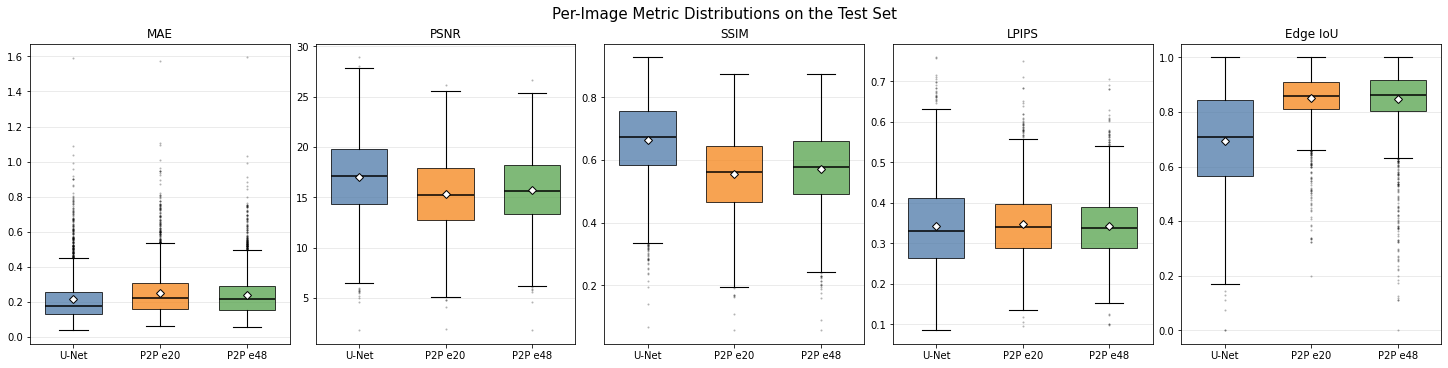

Saved metric-distribution figure to: /content/drive/MyDrive/Sketch2Furniture/figures/test_metric_distributions.png


In [23]:
# Compare Metric Distributions Across Models
short_model_names = {
    "Reconstruction-only U-Net": "U-Net",
    "Pix2Pix epoch 20": "P2P e20",
    "Pix2Pix epoch 48": "P2P e48",
}

model_colors = {
    "Reconstruction-only U-Net": "#4C78A8",
    "Pix2Pix epoch 20": "#F58518",
    "Pix2Pix epoch 48": "#54A24B",
}

figure, axes = plt.subplots(
    1,
    len(performance_metric_columns),
    figsize=(
        4 * len(performance_metric_columns),
        5,
    ),
    constrained_layout=True,
)

for axis, metric_name in zip(
    axes,
    performance_metric_columns,
):
    metric_distributions = [
        evaluation_results.loc[
            evaluation_results["model"]
            == model_name,
            metric_name,
        ].to_numpy()
        for model_name in expected_model_names
    ]

    boxplot_artists = axis.boxplot(
        metric_distributions,
        tick_labels=[
            short_model_names[model_name]
            for model_name in expected_model_names
        ],
        patch_artist=True,
        showmeans=True,
        widths=0.65,
        medianprops={
            "color": "black",
            "linewidth": 1.5,
        },
        meanprops={
            "marker": "D",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": 5,
        },
        whiskerprops={
            "linewidth": 1.1,
        },
        capprops={
            "linewidth": 1.1,
        },
        flierprops={
            "marker": ".",
            "markersize": 2,
            "alpha": 0.3,
        },
    )

    for box, model_name in zip(
        boxplot_artists["boxes"],
        expected_model_names,
    ):
        box.set_facecolor(
            model_colors[model_name]
        )
        box.set_alpha(0.75)

    axis.set_title(
        metric_display_names[metric_name]
    )
    axis.grid(
        alpha=0.3,
        axis="y",
    )
    axis.set_axisbelow(True)

figure.suptitle(
    "Per-Image Metric Distributions on the Test Set",
    fontsize=15,
)

METRIC_DISTRIBUTIONS_PATH = (
    FIGURE_DIR
    / "test_metric_distributions.png"
)

figure.savefig(
    METRIC_DISTRIBUTIONS_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved metric-distribution figure to: "
    f"{METRIC_DISTRIBUTIONS_PATH}"
)

### Observation

The reconstruction-only U-Net achieves the best MAE, PSNR and SSIM, with a mean MAE of 0.2164 against 0.2408 for Pix2Pix epoch 48 and a mean SSIM of 0.6624 against 0.5713. This ordering is consistent with the validation results reported during model selection in Notebooks 03 and 04.

LPIPS does not provide a clear descriptive separation between the reconstruction-only U-Net and Pix2Pix epoch 48. Epoch 48 records the lowest mean LPIPS at 0.3421 against 0.3426 for the baseline, a difference of only 0.0005, while the baseline records the lower median at 0.3312 against 0.3371. The baseline also shows greater variability, with a standard deviation of 0.1070 against 0.0784. Together with its mean being above its median, this suggests a longer upper tail containing perceptually poorer reconstructions.

Round-trip edge IoU separates the models clearly and in the opposite direction, reaching approximately 0.85 for both Pix2Pix checkpoints against 0.6926 for the baseline. This metric measures the tolerant overlap between the conditioning-sketch edges and the edges re-extracted from the generated image using the same Canny configuration. The result therefore indicates that the adversarially trained generators preserve the given contours more faithfully.

Between the two Pix2Pix checkpoints, epoch 48 leads on MAE, PSNR, SSIM and LPIPS, while their edge-IoU results are close. This ordering differs from the qualitative assessment in Notebook 04, where epoch 20 was preferred visually. For all three models, the mean MAE is above the median, which is consistent with right-skewed error distributions and suggests that a subset of test pairs produces considerably higher reconstruction errors. Whether the observed paired differences are statistically reliable is examined in the following subsection.


### Paired Statistical Comparison

## Per-Category Results

## Structural Analysis

## Qualitative Comparison

## Conclusions and Next Steps